In [12]:
import os, glob, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# ---- HARD-CODED PATHS ----
CKPT_PATH = '/zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/weights_all_models_11_4_25/mobilenetv3_small_050.lamb_in1k_maskL_bc_gc_best.pth'
TEST_DIR  = '/zpool/vladlab/active_drive/omaltz/scripts/geogaze/stimuli/out/test_stimuli/test_pairs'  # all test PNGs live here

MAX_PREVIEW = None

# inference settings
ARCH = 'mobilenetv3_small_050.lamb_in1k'  
THRESHOLD = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

# gather PNGs
all_pngs = sorted(glob.glob(os.path.join(TEST_DIR, '*.png')))
if MAX_PREVIEW is not None:
    all_pngs = all_pngs[:MAX_PREVIEW]
print(f'Found {len(all_pngs)} PNGs to preview.')


Found 32 PNGs to preview.


In [13]:
class OneLayerDecoder(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, 1, kernel_size=1)

    def forward(self, feat, out_hw):
        logits = self.proj(feat)
        return F.interpolate(logits, size=out_hw, mode='bilinear', align_corners=False)

class EncoderHead(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.encoder = timm.create_model(backbone, pretrained=True, features_only=True, out_indices=(-1,))
        in_ch = self.encoder.feature_info[-1]['num_chs']
        self.head = OneLayerDecoder(in_ch)

    def forward(self, x):
        feat = self.encoder(x)[0]
        H, W = x.shape[-2:]
        return self.head(feat, (H, W))

model = EncoderHead(ARCH).to(device)
for p in model.encoder.parameters():
    p.requires_grad = False
model.encoder.eval()
ckpt = torch.load(CKPT_PATH, map_location='cpu')
model.load_state_dict(ckpt['state_dict'], strict=True)
model.eval()
print('Loaded checkpoint:', CKPT_PATH)

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Loaded checkpoint: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/weights_all_models_11_4_25/mobilenetv3_small_050.lamb_in1k_maskL_bc_gc_best.pth


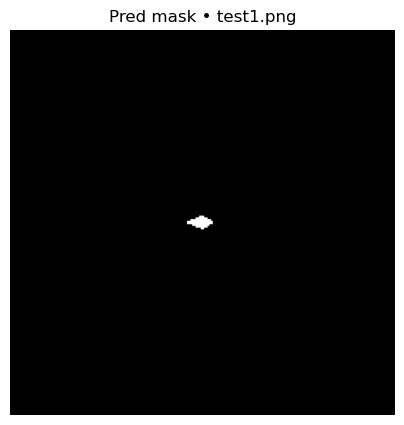

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/stimuli/out/test_output_5/test1.png


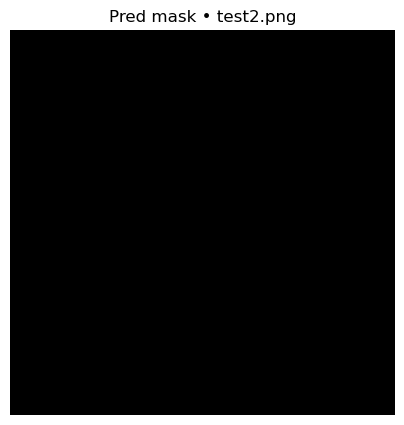

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/stimuli/out/test_output_5/test2.png


FileNotFoundError: [Errno 2] No such file or directory: '/zpool/vladlab/active_drive/omaltz/scripts/geogaze/stimuli/out/test stimuli/test3.png'

In [ ]:
# import os
# import imageio.v2 as imageio

# # where to save predicted mask PNGs
# SAVE_DIR = '/zpool/vladlab/active_drive/omaltz/scripts/geogaze/v2/maskL_bc_gc_model/model_masks'
# os.makedirs(SAVE_DIR, exist_ok=True)


# @torch.no_grad()
# def preprocess_image(path):
#     img = Image.open(path).convert('RGB')
#     arr = np.asarray(img, dtype=np.float32) / 255.0
#     t = torch.from_numpy(arr).permute(2,0,1)
#     t = (t - IMAGENET_MEAN) / IMAGENET_STD
#     return img, t.unsqueeze(0).to(device)

# @torch.no_grad()
# def predict_mask(path, threshold=0.5):
#     pil_img, x = preprocess_image(path)
#     logits = model(x)
#     prob = torch.sigmoid(logits)[0,0].cpu().numpy()
#     pred = (prob > threshold).astype(np.uint8)
#     return pil_img, pred, prob

# assert len(all_pngs) > 0, f'No PNGs found in {TEST_DIR}'

# for p in all_pngs:
#     _, pred, _ = predict_mask(p, threshold=THRESHOLD)

#     # show mask
#     plt.figure(figsize=(5,5))
#     plt.imshow(pred, cmap='gray', vmin=0, vmax=1)
#     plt.title(f'Pred mask • {os.path.basename(p)}')
#     plt.axis('off')
#     plt.show()

#     # save mask as PNG (0/255 grayscale)
#     out_name = os.path.basename(p).replace('pair_', 'pred_')
#     out_path = os.path.join(SAVE_DIR, out_name)
#     imageio.imwrite(out_path, (pred * 255).astype(np.uint8))
#     print('Saved:', out_path)


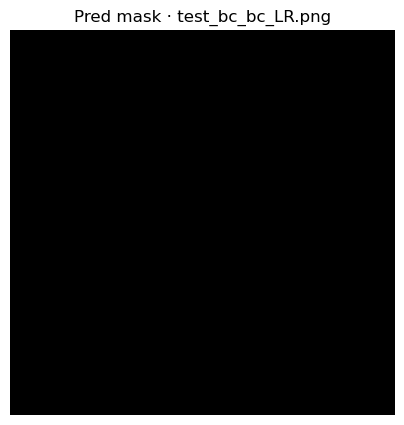

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_bc_LR_R_bcbs_mk.png


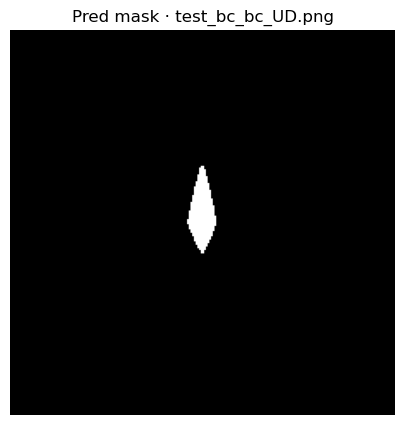

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_bc_UD_R_bcbs_mk.png


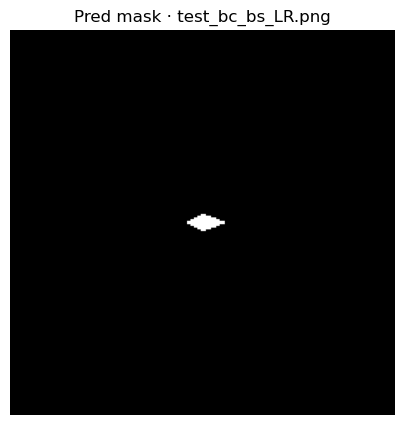

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_bs_LR_R_bcbs_mk.png


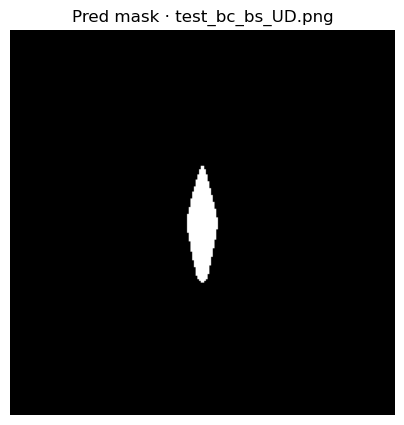

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_bs_UD_R_bcbs_mk.png


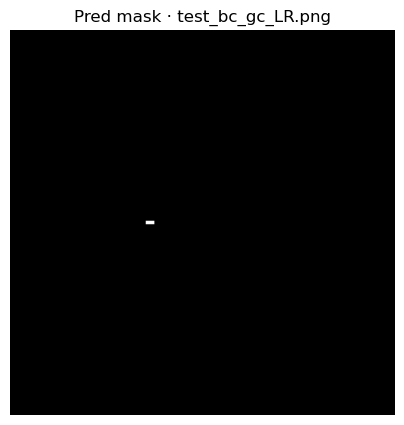

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_gc_LR_R_bcbs_mk.png


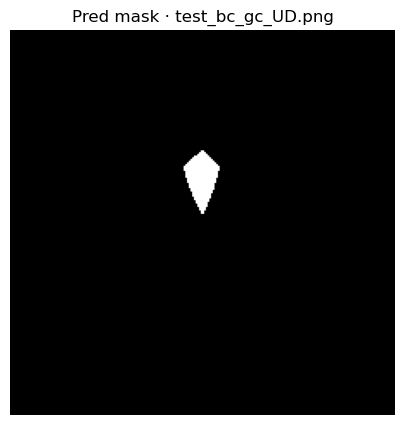

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_gc_UD_R_bcbs_mk.png


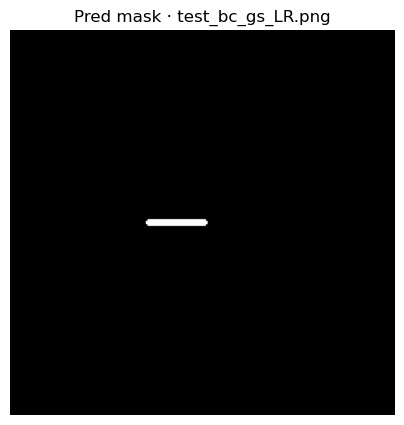

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_gs_LR_R_bcbs_mk.png


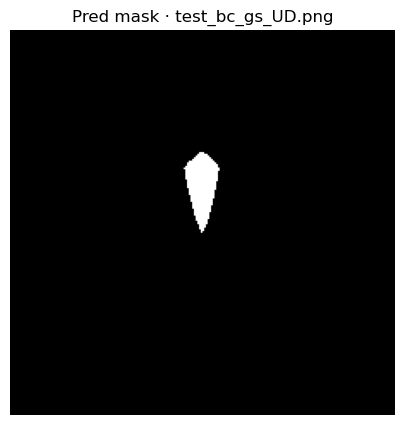

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bc_gs_UD_R_bcbs_mk.png


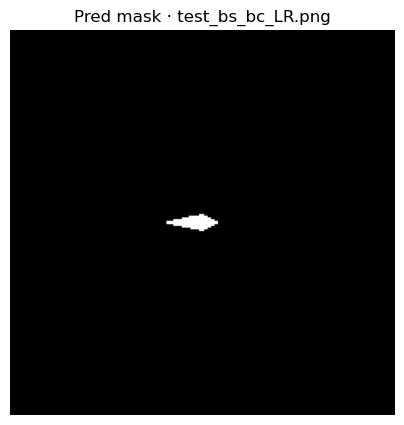

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_bc_LR_R_bcbs_mk.png


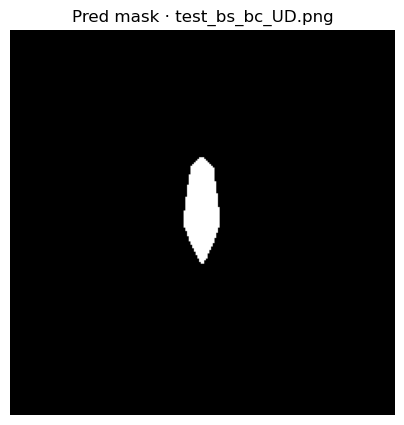

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_bc_UD_R_bcbs_mk.png


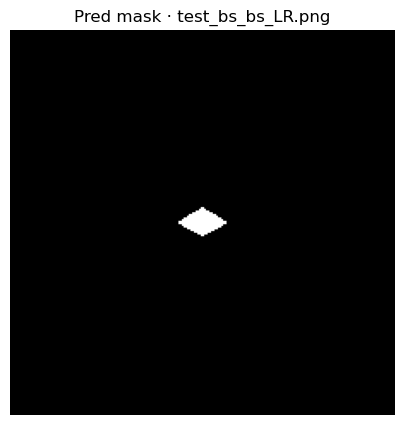

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_bs_LR_R_bcbs_mk.png


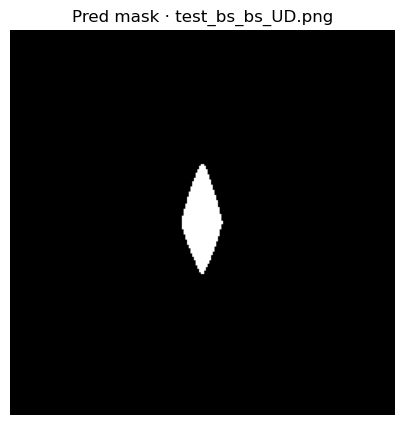

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_bs_UD_R_bcbs_mk.png


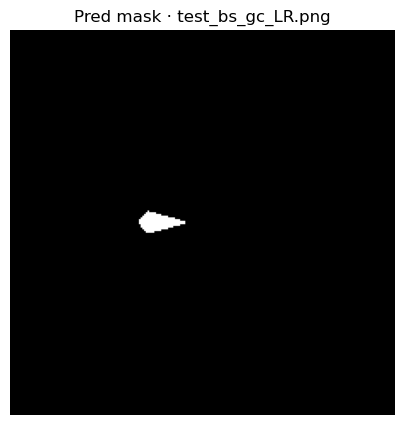

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_gc_LR_R_bcbs_mk.png


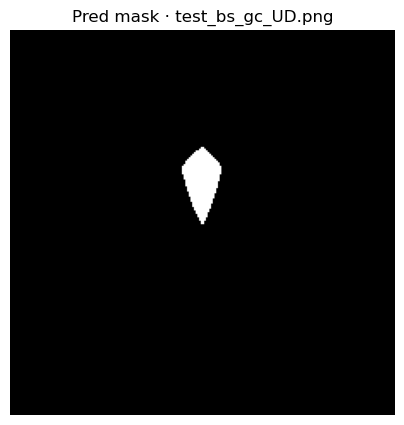

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_gc_UD_R_bcbs_mk.png


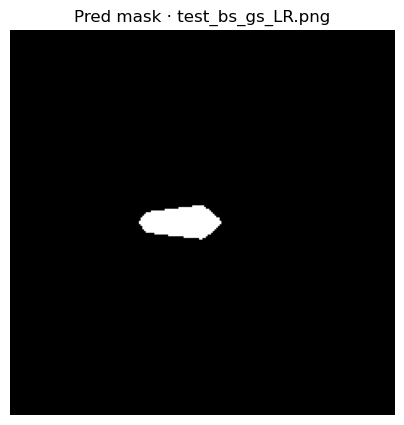

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_gs_LR_R_bcbs_mk.png


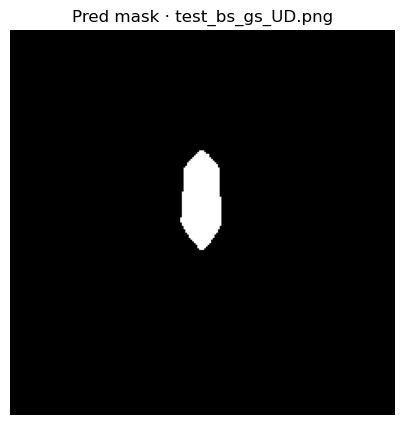

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_bs_gs_UD_R_bcbs_mk.png


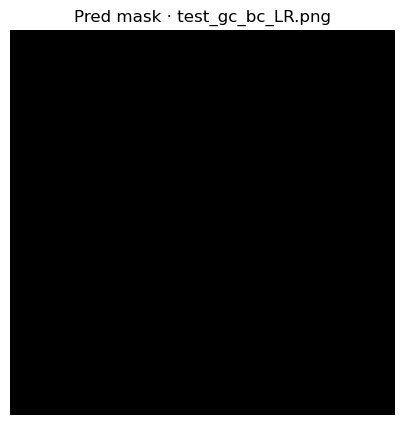

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_bc_LR_R_bcbs_mk.png


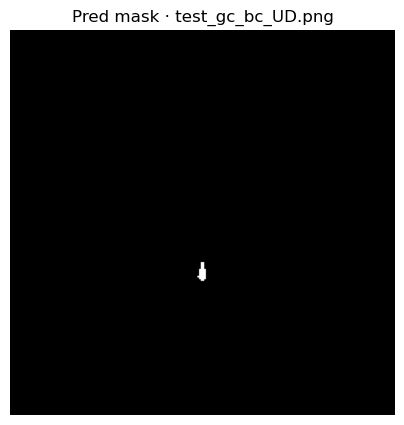

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_bc_UD_R_bcbs_mk.png


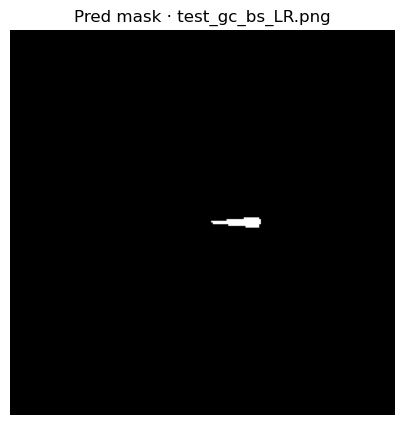

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_bs_LR_R_bcbs_mk.png


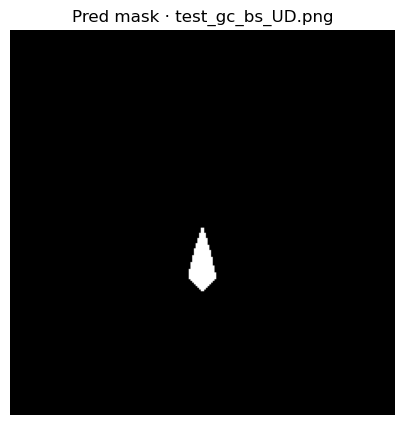

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_bs_UD_R_bcbs_mk.png


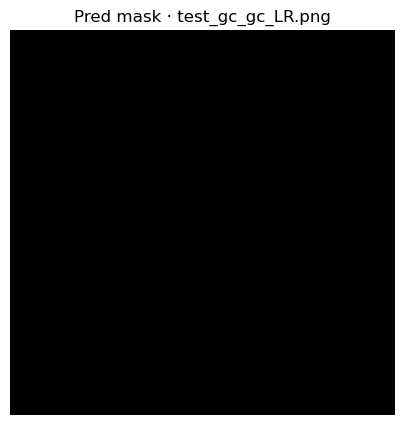

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_gc_LR_R_bcbs_mk.png


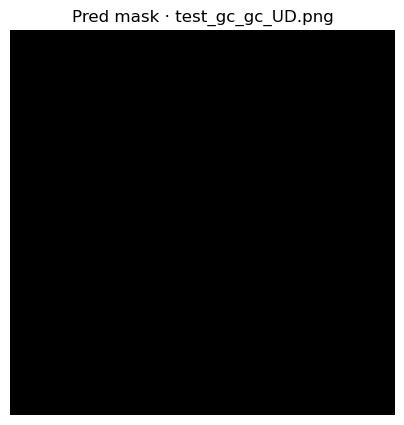

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_gc_UD_R_bcbs_mk.png


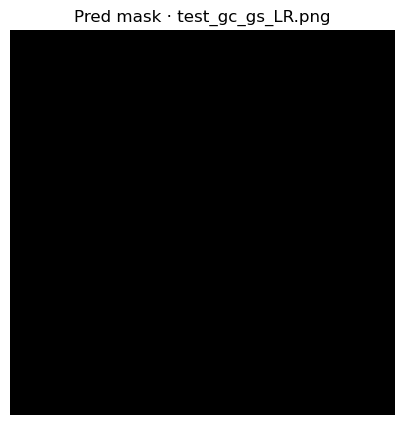

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_gs_LR_R_bcbs_mk.png


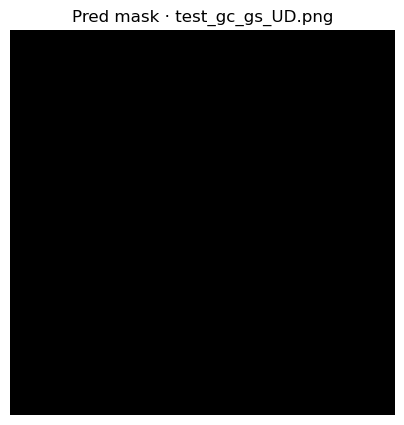

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gc_gs_UD_R_bcbs_mk.png


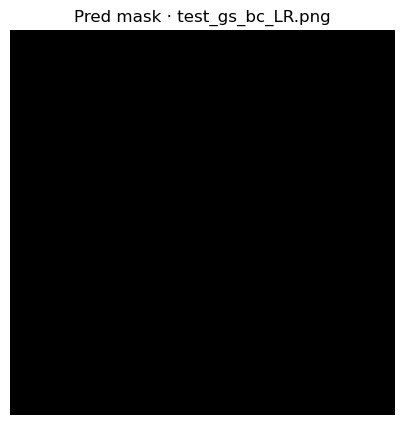

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_bc_LR_R_bcbs_mk.png


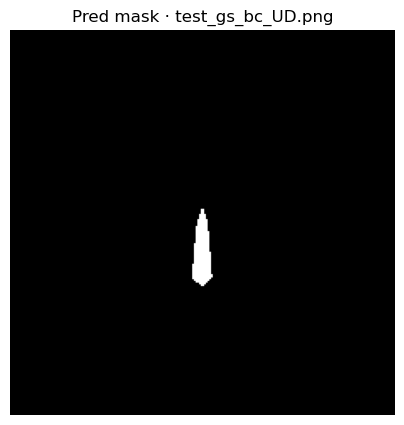

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_bc_UD_R_bcbs_mk.png


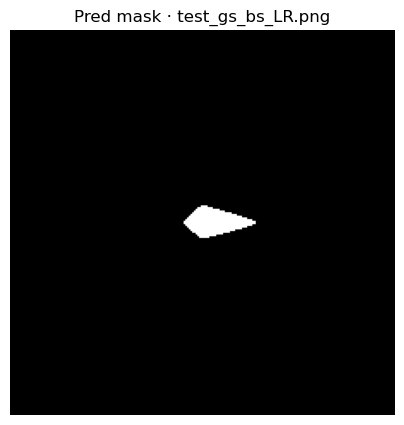

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_bs_LR_R_bcbs_mk.png


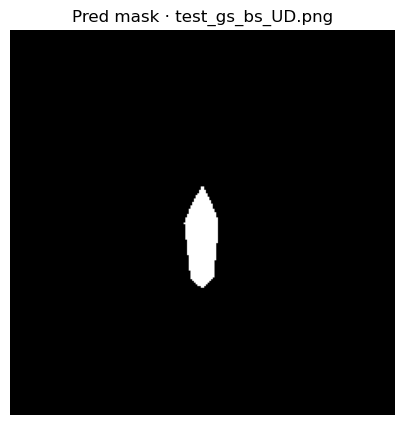

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_bs_UD_R_bcbs_mk.png


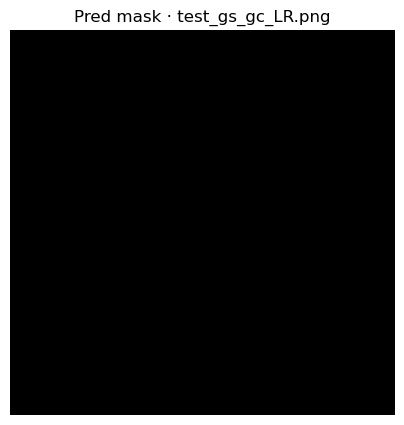

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_gc_LR_R_bcbs_mk.png


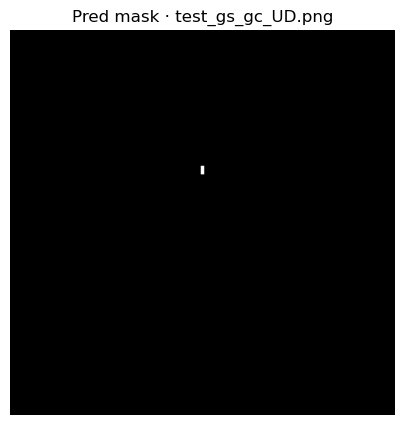

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_gc_UD_R_bcbs_mk.png


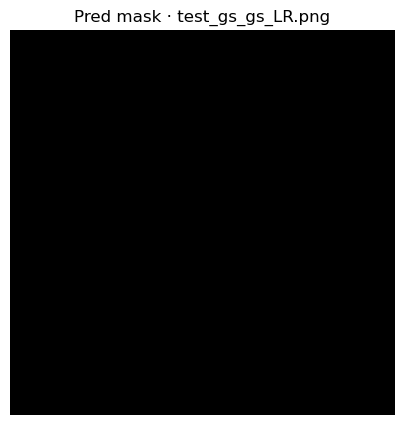

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_gs_LR_R_bcbs_mk.png


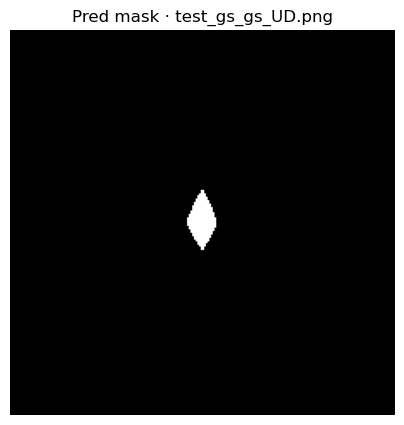

Saved: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25/test_gs_gs_UD_R_bcbs_mk.png


In [14]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torch

# where to save predicted mask PNGs
SAVE_DIR = '/zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/mask_generated_models/mR_BC_BS_11_5_25'
os.makedirs(SAVE_DIR, exist_ok=True)

@torch.no_grad()
def preprocess_image(path):
    img = Image.open(path).convert('RGB')
    arr = np.asarray(img, dtype=np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2, 0, 1)
    t = (t - IMAGENET_MEAN) / IMAGENET_STD
    t = t.unsqueeze(0).to(device)
    return img, t

@torch.no_grad()
def predict_mask(path, threshold=0.5):
    pil_img, x = preprocess_image(path)
    logits = model(x)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred = (prob > threshold).astype(np.uint8)  # 0/1
    return pil_img, pred, prob

assert len(all_pngs) > 0, f'No PNGs found in {TEST_DIR}'

for p in all_pngs:
    _, pred, _ = predict_mask(p, threshold=THRESHOLD)

    # show mask
    plt.figure(figsize=(5, 5))
    plt.imshow(pred, cmap='gray', vmin=0, vmax=1)
    plt.title(f'Pred mask · {os.path.basename(p)}')
    plt.axis('off')
    plt.show()

    # save mask as original filename + _maskL_bcgc_md
    out_name = f"{Path(p).stem}_R_bcbs_mk{Path(p).suffix}"
    out_path = Path(SAVE_DIR) / out_name
    imageio.imwrite(out_path, (pred * 255).astype(np.uint8))  # write as 0/255 PNG
    print('Saved:', out_path)
